In [ ]:
                                             # Logistic Regression (Loan Approval Prdiction)
                                                            #Assignment 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,roc_curve,auc,accuracy_score

In [3]:
df=pd.read_csv('loan approval.csv')
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [ ]:
Problem Statement:- You are working as Data Analyst in a financial institution. The company wants to build a model to
                    predict  wheather a loan application will be approved (1) or not approved (0) based on customer details.

In [ ]:
My task is to perform Exploratory data analysis (EDA), 
build a Logistic Regression Model, evaluate the model, and interpret the results.

In [ ]:
# Question1:- Data Loading and Understanding.
a) Load the dataset into python.
b) Display the first 5 rows.
c) Check the shape of the dataset.
d) Display the data types of each column.
    

In [21]:
#a/b)
df.head(100)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False
...,...,...,...,...,...,...,...,...
95,Aaron Barber,Grimesmouth,51319,795,23618,21,70,True
96,Kimberly Gibson,Mollybury,78520,692,16306,26,75,True
97,Patrick Thornton,Hughesberg,76566,807,3426,8,90,True
98,Leslie Kane,Garciamouth,57460,315,48346,9,30,False


In [15]:
#c) 
df.shape

(2000, 8)

In [16]:
#d)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


In [ ]:
# Question2:- Data Cleaning
a) Check for missing values in the dataset.
b) Handel missing values appropriately.
c) Identify categorical columns present in the dataset.

In [20]:
# a) Missing values in the dataset.
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [26]:
# There no missing values

# b) Change Numeric values median to categorical values mode

for col in df.columns:
    if df[col].dtype=='object':
       df[col].fillna(df[col].mode()[0])
else:
    df[col].fillna(df[col].median())

In [31]:
#c) Identify categorical columns present in the dataset.

cat_cols=df.select_dtypes(include='object').columns
print(cat_cols.tolist())

['name', 'city']


In [30]:
print(cat_cols)

Index(['name', 'city'], dtype='object')


In [ ]:
# Question3:- Exploratory Data Analysis (EDA)
a) Plot the distribution of the target variable.
b) Analyze the relationship between one numerical feature and the target variable.
c) Analyze the relationship between Years of Employmentand the target variable.

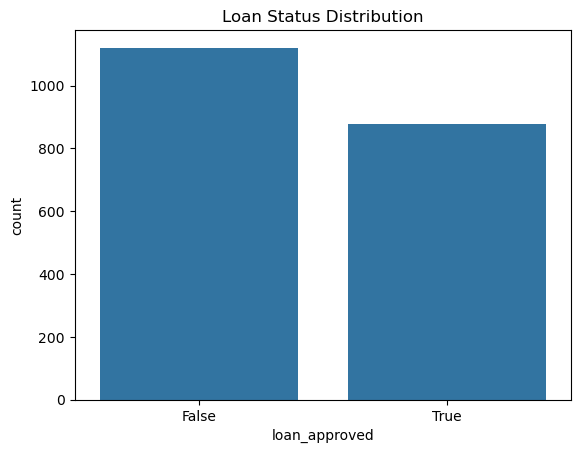

In [8]:
# a) Target variable distribution (Loan Status)
sns.countplot(x='loan_approved',data=df)
plt.title('Loan Status Distribution')
plt.show()

In [ ]:
# b) Analyze the relationship between one numerical feature and the target variable.


Text(0.5, 1.0, 'Loan approved vs credit score')

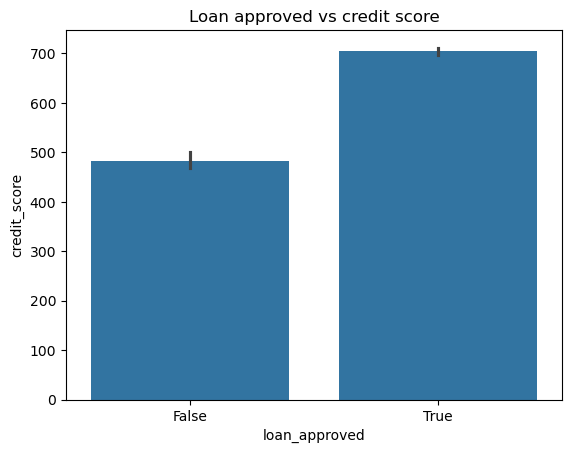

In [14]:
sns.barplot(x='loan_approved',y='credit_score',data=df)
plt.title('Loan approved vs credit score')

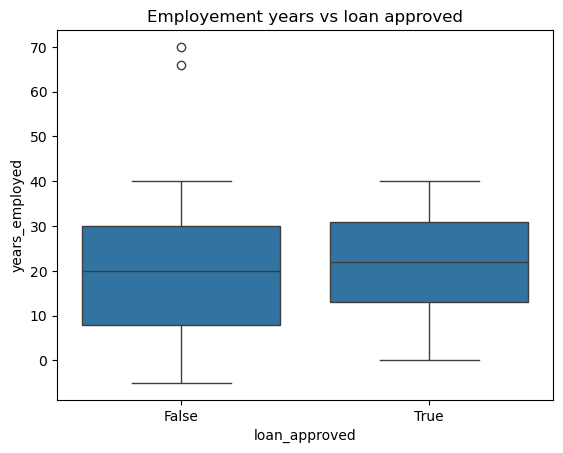

In [16]:
# c) Analyze the relationship between Years of Employmentand the target variable.
sns.boxplot(x='loan_approved',y='years_employed',data=df)
plt.title('Employement years vs loan approved')
plt.show()


Text(0, 0.5, 'Income')

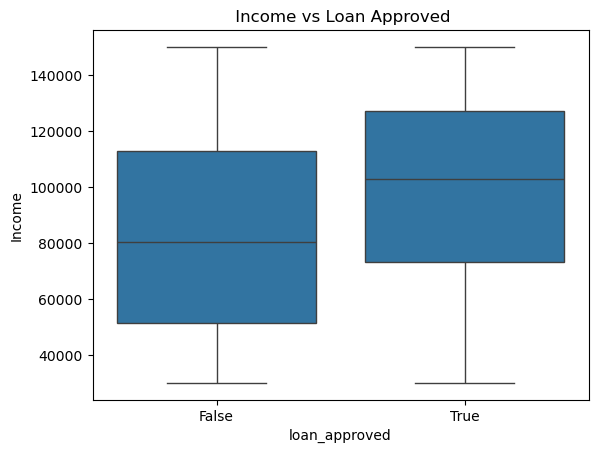

In [67]:
sns.boxplot(x='loan_approved',y='income',data=df)
plt.title(' Income vs Loan Approved')
plt.xlabel('loan_approved')
plt.ylabel('Income')
        

In [ ]:
# Question4:- Outlier Detection and treatment
a) Detect outliers in numerical columns using the IQR method.
b) Treat ouliers using capping techniques.

In [28]:
# Question4:- Outlier Detection and treatment
# a) Detect outliers in numerical columns using the IQR method.
num_cols=df.select_dtypes(include=[np.number,'bool']).columns
# if we drop now it will not show any error
num_cols=num_cols.drop('loan_approved')  # remove the target values
    

In [29]:
for col in num_cols:
    Q1= df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower= Q1-1.5*IQR
    upper= Q3+1.5*IQR
    print(f'{col} Outliers:',len(df[(df[col]<lower)| (df[col]>upper)]))

income Outliers: 0
credit_score Outliers: 3
loan_amount Outliers: 0
years_employed Outliers: 2
points Outliers: 0


In [31]:
# b) Capping se treat karo
for col in num_cols:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR= Q3-Q1
        lower = Q1-1.5*IQR
        upper= Q3+1.5*IQR
        df[col]=np.where(df[col]< lower,lower,df[col])
        df[col]=np.where(df[col]>upper,upper,df[col])

In [ ]:
# Question5:- Convert target variable into numerical format suitable for model 
  building and drop unnecessary columns.

In [ ]:
# Target ka 0/1 me convert karo -  Y/N hai

le=LabelEncoder()
df['loan_approved']=le.fit_transform(df['loan_approved'])  # y=1,n=0

In [33]:
# Unnecessary columns drop karo - 
df.corr(numeric_only=True)

,income,credit_score,loan_amount,years_employed,points,loan_approved
income,1.000000,-0.023379,0.037612,-0.016135,0.451142,0.238066
credit_score,-0.023379,1.000000,-0.006350,0.017390,0.733177,0.707160
loan_amount,0.037612,-0.006350,1.000000,0.009186,-0.223039,-0.157859
years_employed,-0.016135,0.017390,0.009186,1.000000,0.153922,0.101093
points,0.451142,0.733177,-0.223039,0.153922,1.000000,0.821415
loan_approved,0.238066,0.707160,-0.157859,0.101093,0.821415,1.000000


In [ ]:
# Question6:- Feature Selection and Data Spliting
 a) Separate independent variables (x) and dependent variable (y).
 b) Split the dataset into training and testing sets.

In [35]:
X= df.drop('loan_approved',axis=1)
y=df['loan_approved']

In [36]:
# b) Train - test split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [39]:
print(X_train.isnull().sum())

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
dtype: int64


In [40]:
print(X_train.dtypes)

name               object
city               object
income            float64
credit_score      float64
loan_amount       float64
years_employed    float64
points            float64
dtype: object


In [41]:
# now we will drop
X = df.drop(['name','city'],axis=1,errors='ignore')
y = df['loan_approved']

In [42]:
# b) Train - test split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# Question7:- Apply feature scalling to the datasetusing StandardScaler.

In [44]:
# feature scalling
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [45]:
print(X_train.shape)

(1600, 6)


In [46]:
df.shape

(2000, 8)

In [ ]:
# Question8:- Logistic Regression Model Building
   a) Train a Logistic Regression model.
   b) Predict the output for test data.
 

In [47]:
# a) Train Modl
model=LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
# b) prdict
y_pred = model.predict(X_test)

In [ ]:
# Question9:- Model Evaluation - Confusion Matrix
   a)Generate the confusion matrix.
   b) Interpret the results.

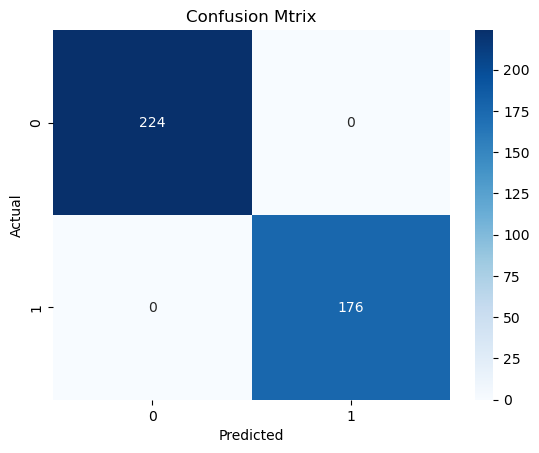

In [50]:
# a) Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Mtrix')
plt.show()

In [52]:
# b) Interpret
print('Classification Report')
print(classification_report(y_test,y_pred))
print('Accuracy', accuracy_score(y_test,y_pred))

Classification Report
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       224
        True       1.00      1.00      1.00       176

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Accuracy 1.0


In [ ]:
# Question10:- Model Evaluation - ROC Curves and AUC
   a) Plot the ROC curve.
   b) Calculate the ROC Score.

In [66]:
from sklearn.metrics import roc_curve,auc   
import matplotlib.pyplot as plt


In [61]:
# a) Plot the ROC curve.
y_prob=model.predict_proba(X_test)[:,1]


In [62]:
# 2. ROC values - 

fpr,tpr,thresholds = roc_curve(y_test,y_prob)

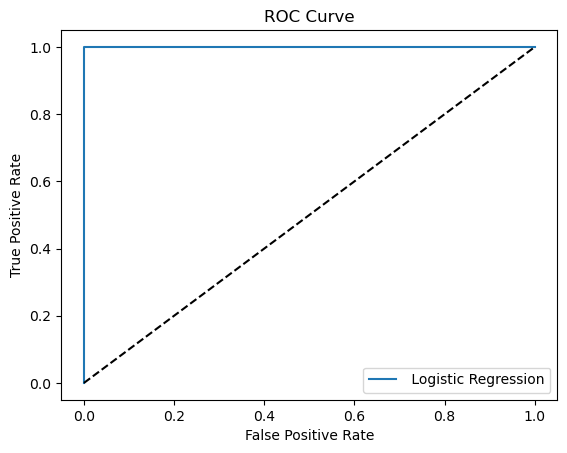

In [65]:
plt.plot(fpr,tpr,label =' Logistic Regression')
plt.plot([0,1],[0,1],'k--') # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()